In [1]:
import pandas as pd

df = pd.read_csv("Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape


(7043, 21)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [8]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [11]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [12]:
df.groupby("Churn")["tenure"].agg(["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
Churn,,,,,
No,5174,37.569965,38.0,0,72
Yes,1869,17.979133,10.0,1,72


In [13]:
df.groupby("Churn")["MonthlyCharges"].agg(["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
Churn,,,,,
No,5174,61.265124,64.425,18.25,118.75
Yes,1869,74.441332,79.650,18.85,118.35


In [14]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check the data type
print("TotalCharges dtype:", df["TotalCharges"].dtype)

# Analyze TotalCharges by churn status
total_charges_analysis = df.groupby("Churn")["TotalCharges"].agg(
    ["count", "mean", "median", "min", "max"]
)

print(total_charges_analysis)

TotalCharges dtype: float64
       count         mean   median    min      max
Churn                                             
No      5163  2555.344141  1683.60  18.80  8672.45
Yes     1869  1531.796094   703.55  18.85  8684.80


In [15]:
df["TotalCharges"].dtype

dtype('float64')

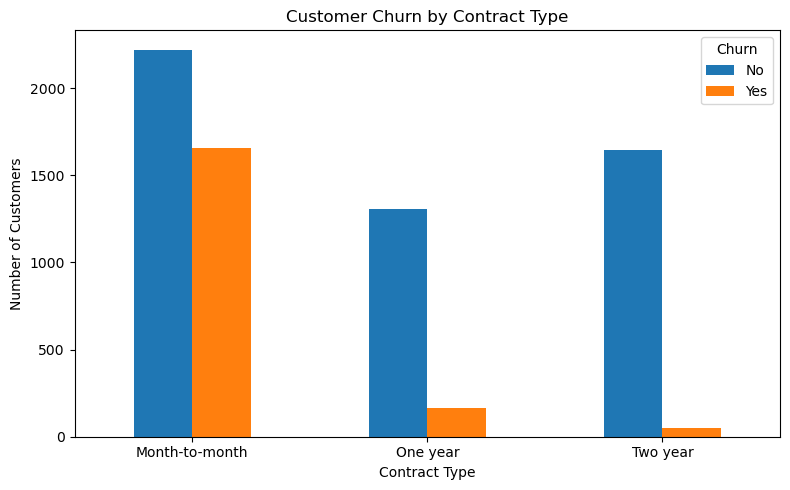

In [16]:
import matplotlib.pyplot as plt

churn_by_contract = pd.crosstab(df["Contract"], df["Churn"])

churn_by_contract.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

In [17]:
%pip install seaborn

In [18]:
%pip install seaborn

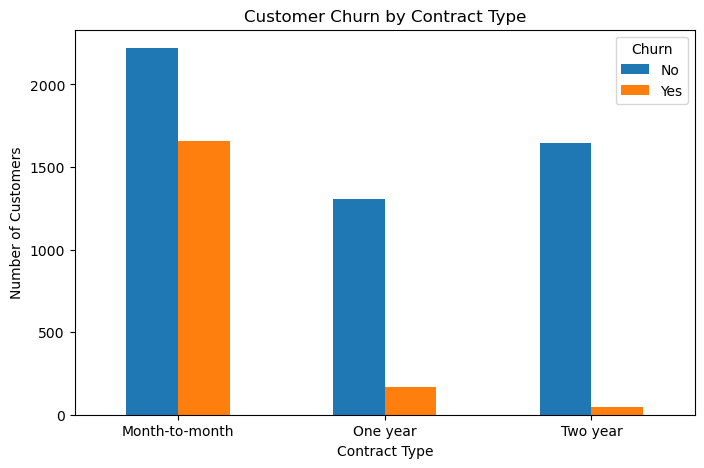

In [19]:
import matplotlib.pyplot as plt

pd.crosstab(df["Contract"], df["Churn"]).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [22]:
import pandas as pd

In [23]:
import matplotlib.pyplot as plt

In [24]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [25]:
print(df.shape)

(7043, 21)


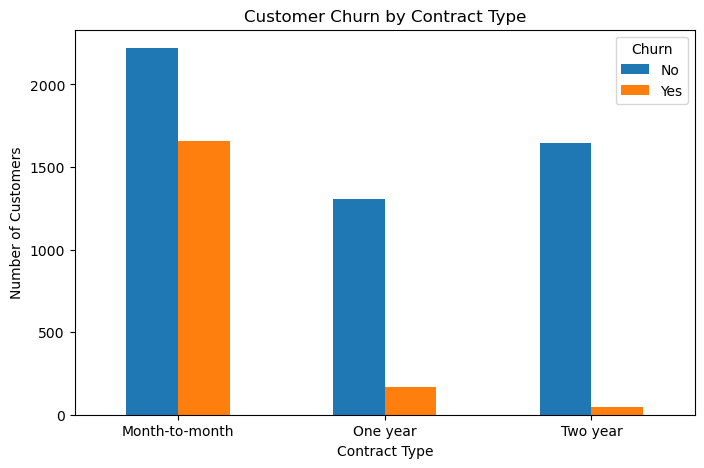

In [26]:
pd.crosstab(df["Contract"], df["Churn"]).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [27]:
pd.crosstab(df["gender"], df["Churn"], normalize="index") * 100

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


In [28]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [29]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [30]:
import pandas as pd

In [31]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [32]:
df.shape

(7043, 21)

In [33]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [34]:
pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


In [35]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [36]:
service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for col in service_columns:
    print("\n", "=" * 50)
    print(col)
    print(pd.crosstab(df[col], df["Churn"], normalize="index") * 100)


OnlineSecurity
Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194

OnlineBackup
Churn                       No        Yes
OnlineBackup                             
No                   60.071244  39.928756
No internet service  92.595020   7.404980
Yes                  78.468506  21.531494

DeviceProtection
Churn                       No        Yes
DeviceProtection                         
No                   60.872375  39.127625
No internet service  92.595020   7.404980
Yes                  77.497936  22.502064

TechSupport
Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341

StreamingTV
Churn                       No        Yes
StreamingTV                              
No

In [37]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [38]:
df["TotalCharges"].dtype

<StringDtype(storage='python', na_value=nan)>

In [39]:
df["TotalCharges"].dtype

<StringDtype(storage='python', na_value=nan)>

In [40]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [41]:
df["TotalCharges"].dtype

dtype('float64')

In [42]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [43]:
df[df["TotalCharges"].isnull()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [44]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [45]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [46]:
df["TotalCharges"].dtype

dtype('float64')

In [47]:
y = df["Churn"]

In [48]:
X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"]

In [49]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [51]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 19)
X_test: (1409, 19)
y_train: (5634,)
y_test: (1409,)


In [52]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "string"]).columns

print("Numerical features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [53]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [54]:
handle_unknown="ignore"

In [55]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

In [56]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [57]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [58]:
y_pred = logistic_model.predict(X_test)

In [59]:
print(y_pred[:20])

['No' 'Yes' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes'
 'No' 'No' 'No' 'Yes' 'No' 'No']


In [60]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8055358410220014


In [61]:
y_pred = logistic_model.predict(X_test)

In [62]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8055358410220014


In [63]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[926 109]
 [165 209]]


In [64]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1035
         Yes       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [65]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[926 109]
 [165 209]]


In [66]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

In [67]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [68]:
rf_pred = rf_model.predict(X_test)

In [69]:
import pandas as pd

In [70]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [71]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [72]:
X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"]

In [73]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object", "string"]
).columns

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [75]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [76]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

In [77]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [78]:
rf_pred = rf_model.predict(X_test)

In [79]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Accuracy: 0.7828246983676366

Classification Report:
              precision    recall  f1-score   support

          No       0.82      0.89      0.86      1035
         Yes       0.62      0.47      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409


Confusion Matrix:
[[926 109]
 [197 177]]


In [80]:
print("Accuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Accuracy: 0.7828246983676366

Classification Report:
              precision    recall  f1-score   support

          No       0.82      0.89      0.86      1035
         Yes       0.62      0.47      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409


Confusion Matrix:
[[926 109]
 [197 177]]


In [81]:
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [82]:
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [83]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

In [84]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [85]:
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [86]:
print(y_prob[:10])

[0.04591993 0.68371345 0.05893985 0.40183529 0.02142426 0.60297803
 0.44762898 0.13033554 0.00280355 0.39473874]


In [87]:
from sklearn.metrics import classification_report

y_pred_40 = (y_prob >= 0.40).astype(int)

y_test_binary = (y_test == "Yes").astype(int)

print(classification_report(y_test_binary, y_pred_40))

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.57      0.67      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



In [88]:
print(classification_report(y_test_binary, y_pred_40))

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.57      0.67      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



In [89]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

for threshold in thresholds:
    predictions = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test_binary, predictions)
    recall = recall_score(y_test_binary, predictions)
    f1 = f1_score(y_test_binary, predictions)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f} | "
        f"F1: {f1:.2f}"
    )

Threshold: 0.20 | Precision: 0.47 | Recall: 0.86 | F1: 0.60
Threshold: 0.25 | Precision: 0.50 | Recall: 0.81 | F1: 0.62
Threshold: 0.30 | Precision: 0.52 | Recall: 0.75 | F1: 0.62
Threshold: 0.35 | Precision: 0.54 | Recall: 0.71 | F1: 0.61
Threshold: 0.40 | Precision: 0.57 | Recall: 0.67 | F1: 0.61
Threshold: 0.45 | Precision: 0.60 | Recall: 0.61 | F1: 0.61
Threshold: 0.50 | Precision: 0.66 | Recall: 0.56 | F1: 0.60
Threshold: 0.55 | Precision: 0.68 | Recall: 0.46 | F1: 0.55
Threshold: 0.60 | Precision: 0.72 | Recall: 0.40 | F1: 0.51


In [90]:
final_threshold = 0.30

final_pred = (y_prob >= final_threshold).astype(int)

print(classification_report(y_test_binary, final_pred))

              precision    recall  f1-score   support

           0       0.89      0.75      0.81      1035
           1       0.52      0.75      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409



In [91]:
df.groupby("Churn")["MonthlyCharges"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Churn,,,,,
No,5174,61.265124,64.425,18.25,118.75
Yes,1869,74.441332,79.650,18.85,118.35


In [92]:
df.groupby("Churn")["MonthlyCharges"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
Churn,,,,,
No,5174,61.27,64.43,18.25,118.75
Yes,1869,74.44,79.65,18.85,118.35


In [93]:
import pandas as pd

categorical_cols = df.select_dtypes(include="object").columns.tolist()

for col in categorical_cols:
    if col != "Churn":
        print(f"\n===== {col} =====")
        print(
            pd.crosstab(
                df[col],
                df["Churn"],
                normalize="index"
            ).round(3) * 100
        )

<ipython-input-93-2fbd74852bd7>:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.tolist()



===== customerID =====
Churn          No    Yes
customerID              
0002-ORFBO  100.0    0.0
0003-MKNFE  100.0    0.0
0004-TLHLJ    0.0  100.0
0011-IGKFF    0.0  100.0
0013-EXCHZ    0.0  100.0
...           ...    ...
9987-LUTYD  100.0    0.0
9992-RRAMN    0.0  100.0
9992-UJOEL  100.0    0.0
9993-LHIEB  100.0    0.0
9995-HOTOH  100.0    0.0

[7043 rows x 2 columns]

===== gender =====
Churn     No   Yes
gender            
Female  73.1  26.9
Male    73.8  26.2

===== Partner =====
Churn      No   Yes
Partner            
No       67.0  33.0
Yes      80.3  19.7

===== Dependents =====
Churn         No   Yes
Dependents            
No          68.7  31.3
Yes         84.5  15.5

===== PhoneService =====
Churn           No   Yes
PhoneService            
No            75.1  24.9
Yes           73.3  26.7

===== MultipleLines =====
Churn               No   Yes
MultipleLines               
No                75.0  25.0
No phone service  75.1  24.9
Yes               71.4  28.6

===== Internet

In [94]:
final_threshold = 0.30

final_pred = (y_prob >= final_threshold).astype(int)

print(classification_report(y_test_binary, final_pred))

              precision    recall  f1-score   support

           0       0.89      0.75      0.81      1035
           1       0.52      0.75      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409



In [95]:
import numpy as np
import pandas as pd

# Get transformed feature names
feature_names = logistic_model.named_steps["preprocessor"].get_feature_names_out()

# Get Logistic Regression coefficients
coefficients = logistic_model.named_steps["model"].coef_[0]

# Create feature importance table
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Impact": np.abs(coefficients)
})

# Sort by absolute impact
feature_importance = feature_importance.sort_values(
    "Absolute_Impact",
    ascending=False
)

print(feature_importance.head(20))

                                       Feature  Coefficient  Absolute_Impact
1                                  num__tenure    -1.257539         1.257539
38                      cat__Contract_Two year    -0.776594         0.776594
15                    cat__InternetService_DSL    -0.648646         0.648646
16            cat__InternetService_Fiber optic     0.634195         0.634195
2                          num__MonthlyCharges    -0.591863         0.591863
36                cat__Contract_Month-to-month     0.582883         0.582883
3                            num__TotalCharges     0.536253         0.536253
39                    cat__PaperlessBilling_No    -0.343227         0.343227
22       cat__OnlineBackup_No internet service    -0.300104         0.300104
17                     cat__InternetService_No    -0.300104         0.300104
25   cat__DeviceProtection_No internet service    -0.300104         0.300104
28        cat__TechSupport_No internet service    -0.300104         0.300104

In [96]:
print(type(X_train))
print(X_train.shape)

<class 'pandas.DataFrame'>
(5634, 19)


In [97]:
print("X_train columns:", len(X_train.columns))
print(
    "Model coefficients:",
    logistic_model.named_steps["model"].coef_.shape
)

X_train columns: 19
Model coefficients: (1, 45)


In [98]:
print(logistic_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str'))])),
                ('model', LogisticRegression(max_iter=1000))])


In [99]:
print(type(logistic_model))

<class 'sklearn.pipeline.Pipeline'>


In [100]:
preprocessor = logistic_model.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

print("Number of transformed features:", len(feature_names))
print(feature_names)

Number of transformed features: 45
['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'cat__gender_Female' 'cat__gender_Male'
 'cat__Partner_No' 'cat__Partner_Yes' 'cat__Dependents_No'
 'cat__Dependents_Yes' 'cat__PhoneService_No' 'cat__PhoneService_Yes'
 'cat__MultipleLines_No' 'cat__MultipleLines_No phone service'
 'cat__MultipleLines_Yes' 'cat__InternetService_DSL'
 'cat__InternetService_Fiber optic' 'cat__InternetService_No'
 'cat__OnlineSecurity_No' 'cat__OnlineSecurity_No internet service'
 'cat__OnlineSecurity_Yes' 'cat__OnlineBackup_No'
 'cat__OnlineBackup_No internet service' 'cat__OnlineBackup_Yes'
 'cat__DeviceProtection_No' 'cat__DeviceProtection_No internet service'
 'cat__DeviceProtection_Yes' 'cat__TechSupport_No'
 'cat__TechSupport_No internet service' 'cat__TechSupport_Yes'
 'cat__StreamingTV_No' 'cat__StreamingTV_No internet service'
 'cat__StreamingTV_Yes' 'cat__StreamingMovies_No'
 'cat__StreamingMovies_No internet service' 'cat__Streamin

In [101]:
# Get the trained Logistic Regression model from the pipeline
model = logistic_model.named_steps["model"]

# Get coefficients
coefficients = model.coef_[0]

# Create feature-importance table
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Add absolute impact
feature_importance["Absolute_Impact"] = (
    feature_importance["Coefficient"].abs()
)

# Sort by strongest impact
feature_importance = feature_importance.sort_values(
    "Absolute_Impact",
    ascending=False
)

feature_importance.head(20)

,Feature,Coefficient,Absolute_Impact
1,num__tenure,-1.257539,1.257539
38,cat__Contract_Two year,-0.776594,0.776594
15,cat__InternetService_DSL,-0.648646,0.648646
16,cat__InternetService_Fiber optic,0.634195,0.634195
2,num__MonthlyCharges,-0.591863,0.591863
36,cat__Contract_Month-to-month,0.582883,0.582883
3,num__TotalCharges,0.536253,0.536253
39,cat__PaperlessBilling_No,-0.343227,0.343227
22,cat__OnlineBackup_No internet service,-0.300104,0.300104
17,cat__InternetService_No,-0.300104,0.300104


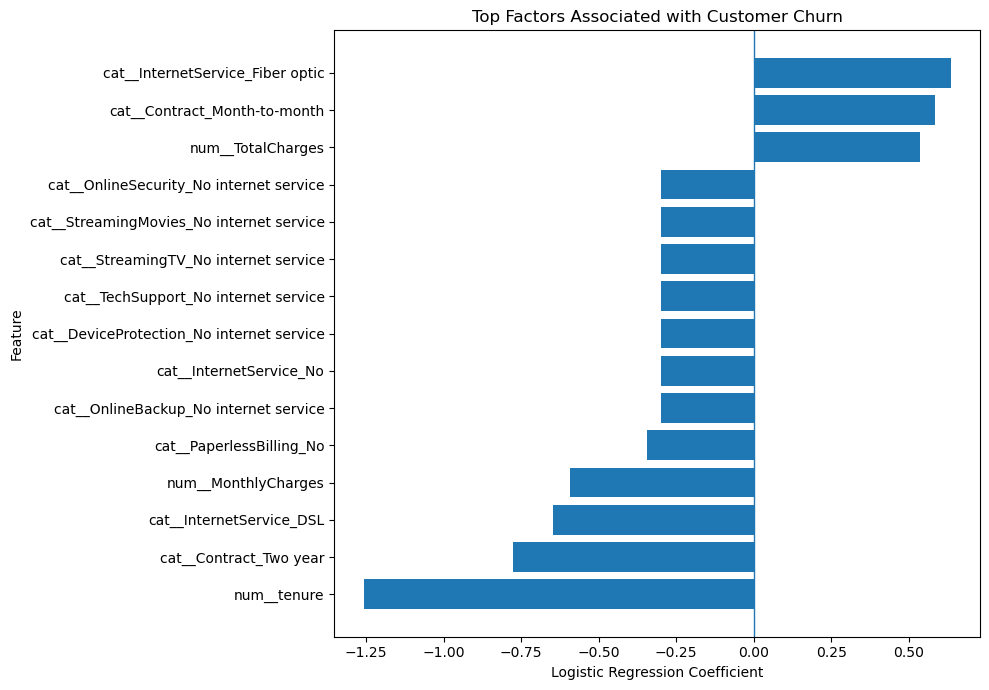

In [102]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15).sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top Factors Associated with Customer Churn")

plt.tight_layout()
plt.show()

In [103]:
contract_churn = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
    .round(2)
)

print(contract_churn)

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64


In [104]:
internet_churn = (
    df.groupby("InternetService")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
    .round(2)
)

print(internet_churn)

InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn, dtype: float64


In [105]:
segment_churn = (
    df.groupby(["Contract", "InternetService"])["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
    .sort_values("ChurnRate", ascending=False)
)

segment_churn.round(2)

,Contract,InternetService,ChurnRate
1,Month-to-month,Fiber optic,54.61
0,Month-to-month,DSL,32.22
4,One year,Fiber optic,19.29
2,Month-to-month,No,18.89
3,One year,DSL,9.30
7,Two year,Fiber optic,7.23
5,One year,No,2.47
6,Two year,DSL,1.91
8,Two year,No,0.78


In [106]:
high_risk = df[
    (df["Contract"] == "Month-to-month") &
    (df["InternetService"] == "Fiber optic")
]

print("Number of customers:", len(high_risk))

print("\nPercentage of all customers:",
      round(len(high_risk) / len(df) * 100, 2), "%")

print("\nChurn rate:",
      round((high_risk["Churn"] == "Yes").mean() * 100, 2), "%")

print("\nAverage tenure:",
      round(high_risk["tenure"].mean(), 2), "months")

print("\nAverage monthly charges:",
      round(high_risk["MonthlyCharges"].mean(), 2))

print("\nAverage total charges:",
      round(high_risk["TotalCharges"].mean(), 2))

Number of customers: 2128

Percentage of all customers: 30.21 %

Churn rate: 54.61 %

Average tenure: 21.55 months

Average monthly charges: 87.02

Average total charges: 1969.71


In [107]:
high_risk_churners = high_risk[high_risk["Churn"] == "Yes"]

print("High-risk customers:", len(high_risk))
print("High-risk churners:", len(high_risk_churners))

print(
    "Share of all churners:",
    round(len(high_risk_churners) / (df["Churn"] == "Yes").sum() * 100, 2),
    "%"
)

High-risk customers: 2128
High-risk churners: 1162
Share of all churners: 62.17 %


In [108]:
monthly_revenue_exposure = (
    high_risk_churners["MonthlyCharges"].sum()
)

print(
    "Monthly revenue currently associated with churned high-risk customers:",
    round(monthly_revenue_exposure, 2)
)

Monthly revenue currently associated with churned high-risk customers: 100482.0


In [109]:
potential_monthly_revenue = high_risk["MonthlyCharges"].sum()

print(
    "Total monthly revenue represented by the high-risk segment:",
    round(potential_monthly_revenue, 2)
)


Total monthly revenue represented by the high-risk segment: 185181.1


In [110]:
churned_revenue = high_risk_churners["MonthlyCharges"].sum()

for retention_rate in [0.10, 0.20, 0.30]:
    retained_revenue = churned_revenue * retention_rate
    
    print(
        f"{int(retention_rate * 100)}% retention scenario: "
        f"{retained_revenue:,.2f} per month"
    )

10% retention scenario: 10,048.20 per month
20% retention scenario: 20,096.40 per month
30% retention scenario: 30,144.60 per month


In [111]:
risk_df = X_test.copy()

risk_df["Actual_Churn"] = y_test_binary.values
risk_df["Churn_Probability"] = y_prob
risk_df["Predicted_Churn"] = final_pred

risk_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual_Churn,Churn_Probability,Predicted_Churn
437,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,0,0.045920,0
2280,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,0,0.683713,1
2235,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,Yes,...,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20,0,0.058940,0
4460,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,No,Electronic check,78.20,1468.75,0,0.401835,1
3761,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,0,0.021424,0


In [112]:
def risk_category(probability):
    if probability >= 0.60:
        return "High Risk"
    elif probability >= 0.30:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_df["Risk_Category"] = risk_df["Churn_Probability"].apply(
    risk_category
)

print(risk_df["Risk_Category"].value_counts())

print("\nRisk percentages:")
print(
    (risk_df["Risk_Category"].value_counts(normalize=True) * 100)
    .round(2)
)

Risk_Category
Low Risk       866
Medium Risk    334
High Risk      209
Name: count, dtype: int64

Risk percentages:
Risk_Category
Low Risk       61.46
Medium Risk    23.70
High Risk      14.83
Name: proportion, dtype: float64


In [113]:
risk_summary = (
    risk_df.groupby("Risk_Category")
    .agg(
        Customers=("Churn_Probability", "size"),
        Average_Churn_Probability=("Churn_Probability", "mean"),
        Actual_Churn_Rate=("Actual_Churn", "mean")
    )
    .round(3)
)

risk_summary

,Customers,Average_Churn_Probability,Actual_Churn_Rate
Risk_Category,,,
High Risk,209,0.694,0.718
Low Risk,866,0.094,0.106
Medium Risk,334,0.451,0.395


In [114]:
print(risk_summary)

               Customers  Average_Churn_Probability  Actual_Churn_Rate
Risk_Category                                                         
High Risk            209                      0.694              0.718
Low Risk             866                      0.094              0.106
Medium Risk          334                      0.451              0.395


In [115]:
risk_dashboard = (
    risk_df.groupby("Risk_Category")
    .agg(
        Customers=("Churn_Probability", "size"),
        Average_Probability=("Churn_Probability", "mean"),
        Actual_Churn_Rate=("Actual_Churn", "mean")
    )
    .reset_index()
)

risk_dashboard["Average_Probability"] *= 100
risk_dashboard["Actual_Churn_Rate"] *= 100

risk_dashboard = risk_dashboard.round(2)

risk_dashboard

,Risk_Category,Customers,Average_Probability,Actual_Churn_Rate
0,High Risk,209,69.40,71.77
1,Low Risk,866,9.44,10.62
2,Medium Risk,334,45.06,39.52


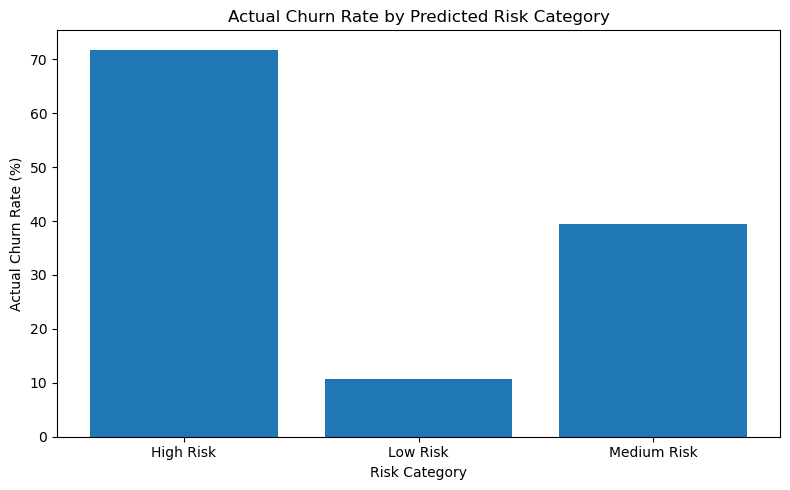

In [116]:
plt.figure(figsize=(8, 5))

plt.bar(
    risk_dashboard["Risk_Category"],
    risk_dashboard["Actual_Churn_Rate"]
)

plt.xlabel("Risk Category")
plt.ylabel("Actual Churn Rate (%)")
plt.title("Actual Churn Rate by Predicted Risk Category")

plt.tight_layout()
plt.show()

In [117]:
priority_customers = risk_df[
    risk_df["Risk_Category"] == "High Risk"
].sort_values(
    "Churn_Probability",
    ascending=False
)

priority_customers[
    [
        "Churn_Probability",
        "Actual_Churn",
        "Contract",
        "InternetService",
        "tenure",
        "MonthlyCharges",
        "TotalCharges"
    ]
].head(20)

,Churn_Probability,Actual_Churn,Contract,InternetService,tenure,MonthlyCharges,TotalCharges
3380,0.854280,1,Month-to-month,Fiber optic,1,95.10,95.10
6866,0.831583,1,Month-to-month,Fiber optic,1,95.45,95.45
2631,0.828147,1,Month-to-month,Fiber optic,7,99.25,665.45
6365,0.821692,1,Month-to-month,Fiber optic,7,101.95,700.85
4585,0.818493,1,Month-to-month,Fiber optic,1,85.05,85.05
2797,0.817586,1,Month-to-month,Fiber optic,3,100.95,329.95
3346,0.817334,0,Month-to-month,Fiber optic,2,84.05,186.05
3727,0.817042,1,Month-to-month,Fiber optic,3,96.60,291.90
6894,0.815703,1,Month-to-month,Fiber optic,3,105.90,334.65
935,0.811504,0,Month-to-month,Fiber optic,4,83.25,308.05


In [118]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Accuracy :", round(accuracy_score(y_test_binary, final_pred), 4))
print("Precision:", round(precision_score(y_test_binary, final_pred), 4))
print("Recall   :", round(recall_score(y_test_binary, final_pred), 4))
print("F1 Score :", round(f1_score(y_test_binary, final_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test_binary, y_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_binary, final_pred))

Accuracy : 0.7495
Precision: 0.5193
Recall   : 0.754
F1 Score : 0.615
ROC-AUC  : 0.8421

Confusion Matrix:
[[774 261]
 [ 92 282]]


In [119]:
from sklearn.ensemble import RandomForestClassifier

In [120]:
random_forest = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

In [121]:
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", random_forest)
])

In [122]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [123]:
rf_pred = rf_pipeline.predict(X_test)

rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")
print("Number of predictions:", len(rf_pred))

Predictions generated successfully.
Number of predictions: 1409


In [124]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Convert Yes/No predictions to 0/1
rf_pred_binary = (rf_pred == "Yes").astype(int)

# Random Forest evaluation
print("Random Forest Performance")
print("-" * 30)

print("Accuracy :", round(accuracy_score(y_test_binary, rf_pred_binary), 4))
print("Precision:", round(precision_score(y_test_binary, rf_pred_binary), 4))
print("Recall   :", round(recall_score(y_test_binary, rf_pred_binary), 4))
print("F1 Score :", round(f1_score(y_test_binary, rf_pred_binary), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test_binary, rf_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_binary, rf_pred_binary))

Random Forest Performance
------------------------------
Accuracy : 0.7835
Precision: 0.6211
Recall   : 0.4733
F1 Score : 0.5372
ROC-AUC  : 0.8227

Confusion Matrix:
[[927 108]
 [197 177]]


In [125]:
print(type(rf_pipeline))

print("rf_pred exists:", "rf_pred" in globals())
print("rf_prob exists:", "rf_prob" in globals())
print("y_test_binary exists:", "y_test_binary" in globals())

<class 'sklearn.pipeline.Pipeline'>
rf_pred exists: True
rf_prob exists: True
y_test_binary exists: True


In [126]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Random Forest Performance")
print("-" * 30)

print("Accuracy :", round(accuracy_score(y_test_binary, rf_pred_binary), 4))
print("Precision:", round(precision_score(y_test_binary, rf_pred_binary), 4))
print("Recall   :", round(recall_score(y_test_binary, rf_pred_binary), 4))
print("F1 Score :", round(f1_score(y_test_binary, rf_pred_binary), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test_binary, rf_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_binary, rf_pred_binary))

Random Forest Performance
------------------------------
Accuracy : 0.7835
Precision: 0.6211
Recall   : 0.4733
F1 Score : 0.5372
ROC-AUC  : 0.8227

Confusion Matrix:
[[927 108]
 [197 177]]


In [127]:
rf_pred_binary = (rf_pred == "Yes").astype(int)

print("Unique RF predictions:", set(rf_pred_binary))
print("Unique actual labels:", set(y_test_binary))

Unique RF predictions: {np.int32(0), np.int32(1)}
Unique actual labels: {0, 1}


In [128]:
print("Random Forest Performance")
print("-" * 30)

print("Accuracy :", round(accuracy_score(y_test_binary, rf_pred_binary), 4))
print("Precision:", round(precision_score(y_test_binary, rf_pred_binary), 4))
print("Recall   :", round(recall_score(y_test_binary, rf_pred_binary), 4))
print("F1 Score :", round(f1_score(y_test_binary, rf_pred_binary), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test_binary, rf_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_binary, rf_pred_binary))

Random Forest Performance
------------------------------
Accuracy : 0.7835
Precision: 0.6211
Recall   : 0.4733
F1 Score : 0.5372
ROC-AUC  : 0.8227

Confusion Matrix:
[[927 108]
 [197 177]]


In [129]:
rf_pred_30 = (rf_prob >= 0.30).astype(int)

print("Random Forest at 0.30 threshold")
print("-" * 35)

print("Accuracy :", round(accuracy_score(y_test_binary, rf_pred_30), 4))
print("Precision:", round(precision_score(y_test_binary, rf_pred_30), 4))
print("Recall   :", round(recall_score(y_test_binary, rf_pred_30), 4))
print("F1 Score :", round(f1_score(y_test_binary, rf_pred_30), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_binary, rf_pred_30))

Random Forest at 0.30 threshold
-----------------------------------
Accuracy : 0.7488
Precision: 0.5197
Recall   : 0.7059
F1 Score : 0.5986

Confusion Matrix:
[[791 244]
 [110 264]]


# Customer Churn Prediction & Retention Analytics

## 1. Business Problem

Customer churn is a major challenge for subscription-based businesses. 
When customers leave, companies lose recurring revenue and must spend additional 
resources to acquire replacement customers.

The objective of this project is to:

- Analyze customer churn patterns
- Identify the factors associated with customer churn
- Build a machine learning model to predict customers at risk of churning
- Segment customers into different risk categories
- Identify high-risk customer segments
- Estimate the potential revenue impact of customer retention

### Business Question

> Which customers are most likely to churn, what factors are associated with 
> churn, and where should the business prioritize retention efforts?

### Project Approach

The project combines:

1. Exploratory Data Analysis
2. Statistical and categorical analysis
3. Logistic Regression
4. Random Forest
5. Churn probability scoring
6. Customer risk segmentation
7. Business impact analysis

## 2. Dataset & Objective

### Dataset

The dataset contains customer-level information from a telecommunications
service provider.

Each row represents one customer, while the columns contain information about:

- Demographic characteristics
- Account information
- Services subscribed to
- Contract type
- Payment method
- Monthly charges
- Total charges
- Customer churn status

### Target Variable

**Churn** is the target variable.

- `Yes` → Customer churned
- `No` → Customer did not churn

For machine learning, the target was encoded as:

- `1` → Churn
- `0` → No churn

### Dataset Size

After preprocessing, the dataset contains:

- **5,634 customers**
- **19 original features**

### Objective

The primary objective is to estimate the probability that a customer will
churn and use these predictions to identify customers who may require
retention attention.

## 3. Data Cleaning & Preprocessing

Before performing exploratory analysis and machine learning, the dataset was
checked and prepared for analysis.

### Cleaning steps

- Checked the dataset dimensions and data types.
- Identified missing and inconsistent values.
- Converted `TotalCharges` from text to numeric format.
- Handled invalid or blank `TotalCharges` values as missing values.
- Verified numerical and categorical variables.
- Converted the target variable `Churn` into a binary format for machine learning:
  - `Yes` → `1`
  - `No` → `0`

### Feature Types

**Numerical features:**
- SeniorCitizen
- tenure
- MonthlyCharges
- TotalCharges

**Categorical features:**
- gender
- Partner
- Dependents
- PhoneService
- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies
- Contract
- PaperlessBilling
- PaymentMethod

### Preprocessing for Machine Learning

A preprocessing pipeline was used to:

- Standardize numerical variables using `StandardScaler`
- Encode categorical variables using `OneHotEncoder`
- Handle previously unseen categorical values using `handle_unknown="ignore"`

This preprocessing approach ensures that the same transformations are applied
consistently to training and test data.

## 4. Exploratory Data Analysis

Exploratory Data Analysis (EDA) was performed to understand customer
characteristics and identify patterns associated with churn.

### Key areas investigated

- Overall customer churn distribution
- Churn by contract type
- Churn by internet service
- Customer tenure and churn
- Monthly charges and churn
- Total charges and churn
- Interaction between contract type and internet service

### Purpose of EDA

The analysis focuses on identifying customer groups with substantially
different churn rates.

Particular attention is given to contract type and internet service because
these variables show strong differences in observed churn rates.

The EDA provides the business context for the subsequent machine learning
and customer-risk analysis.

## 5. Key Churn Drivers

The analysis identified several customer characteristics strongly associated
with differences in churn probability.

### Major observations

#### Contract Type

Observed churn rates:

- Month-to-month: **42.71%**
- One year: **11.27%**
- Two year: **2.83%**

Customers on month-to-month contracts show substantially higher churn than
customers on longer-term contracts.

#### Internet Service

Observed churn rates:

- Fiber optic: **41.89%**
- DSL: **18.96%**
- No internet service: **7.40%**

Fiber-optic customers show a substantially higher observed churn rate in this
dataset.

#### Contract × Internet Service

The highest-risk combination identified was:

**Month-to-month + Fiber optic**

Observed churn rate: **54.61%**

Other combinations showed substantially lower churn rates.

### Logistic Regression Findings

The Logistic Regression model also identified tenure and contract-related
variables among the strongest model associations.

The coefficient analysis should be interpreted as association rather than
causation.

### Business Interpretation

The results suggest that retention strategies should prioritize customers
with short-term contracts and characteristics associated with higher predicted
churn probability, rather than treating every customer as equally likely to
leave.

## 6. Predictive Modeling

Machine learning models were developed to estimate the probability of customer
churn.

### Models Used

Two classification models were evaluated:

1. **Logistic Regression**
2. **Random Forest**

### Logistic Regression

Logistic Regression was used as the primary interpretable classification
model.

Advantages:

- Provides churn probabilities
- Easy to interpret
- Coefficients can be examined to understand feature associations
- Suitable as a strong baseline for binary classification

### Random Forest

Random Forest was evaluated as a nonlinear comparison model.

It can capture more complex relationships between customer characteristics
without assuming a linear relationship between features and churn.

### Preprocessing

The machine-learning pipeline applied:

- Standardization of numerical variables
- One-hot encoding of categorical variables
- Consistent preprocessing between training and test data

### Model Objective

The primary objective was not simply to maximize accuracy.

Because customer retention is the business objective, identifying customers
who are likely to churn is particularly important. Therefore, recall,
precision, F1-score and ROC-AUC were considered alongside accuracy.

## 7. Model Evaluation

The models were evaluated using multiple classification metrics.

### Logistic Regression

At the selected probability threshold of **0.30**:

- **Accuracy:** 74.95%
- **Precision:** 51.93%
- **Recall:** 75.40%
- **F1 Score:** 61.50%
- **ROC-AUC:** 0.8421

Confusion Matrix:

|                | Predicted No | Predicted Yes |
|----------------|--------------|---------------|
| Actual No      | 774          | 261           |
| Actual Yes     | 92           | 282           |

### Random Forest

At the default threshold of **0.50**:

- **Accuracy:** 78.35%
- **Precision:** 62.11%
- **Recall:** 47.33%
- **F1 Score:** 53.72%
- **ROC-AUC:** 0.8227

Confusion Matrix:

|                | Predicted No | Predicted Yes |
|----------------|--------------|---------------|
| Actual No      | 927          | 108           |
| Actual Yes     | 197          | 177           |

### Model Selection

Although Random Forest achieved higher accuracy at the default threshold,
Logistic Regression achieved higher recall and ROC-AUC.

Since the business objective emphasizes identifying customers who may churn,
Logistic Regression with the **0.30 threshold** provides a more useful
retention-oriented configuration.

The lower threshold increases the number of customers identified as
potential churners, allowing the business to intervene with more potential
at-risk customers.

## 8. Customer Risk Segmentation

The predicted churn probabilities were converted into three customer risk
categories to make the model outputs easier to use for business decision-making.

### Risk Categories

- **Low Risk:** Customers with relatively low predicted churn probability
- **Medium Risk:** Customers with moderate predicted churn probability
- **High Risk:** Customers with high predicted churn probability

### Risk Segment Performance

| Risk Category | Customers | Average Churn Probability | Actual Churn Rate |
|---|---:|---:|---:|
| Low Risk | 866 | 9.4% | 10.6% |
| Medium Risk | 334 | 45.1% | 39.5% |
| High Risk | 209 | 69.4% | 71.8% |

### Key Finding

The High Risk segment has an actual churn rate of **71.8%**, closely matching
its average predicted churn probability of **69.4%**.

This indicates that the risk segmentation provides a useful way of prioritizing
customers for retention activities.

### Business Use

Rather than applying the same retention strategy to every customer, the
business can prioritize:

1. High-risk customers for immediate intervention
2. Medium-risk customers for targeted preventive action
3. Low-risk customers for regular engagement

## 9. High-Risk Customer Segment

Further segmentation was performed to identify a specific customer group with
particularly high observed churn.

### Highest-Risk Segment

The highest-risk combination identified was:

**Month-to-month contract + Fiber optic internet service**

| Metric | Value |
|---|---:|
| Number of customers | 2,128 |
| Share of all customers | 30.21% |
| Churn rate | 54.61% |
| Average tenure | 21.55 months |
| Average monthly charges | 87.02 |
| Average total charges | 1,969.71 |

### Churn Contribution

This segment contained:

- **1,162 churned customers**
- **62.17% of all churners**

### Business Interpretation

This segment represents a major concentration of churn.

Therefore, a retention strategy should prioritize customers with this
combination of contract and service characteristics, particularly those with
high predicted churn probability.

The analysis does not establish that the contract type or internet service
causes churn. Instead, these characteristics identify a customer segment with
a high observed churn rate in the dataset.

## 10. Revenue Impact & Retention Scenarios

The high-risk segment represents a significant amount of recurring monthly
revenue.

### Revenue Exposure

The total monthly charges associated with customers in the high-risk segment
are:

**185,181.10 per month**

Among these customers, the monthly charges associated with customers who
actually churned were:

**100,482.00 per month**

### Retention Scenarios

To estimate the potential business impact of retention efforts, three simple
scenarios were evaluated.

| Retention Scenario | Potential Monthly Revenue Retained |
|---|---:|
| 10% | 10,048.20 |
| 20% | 20,096.40 |
| 30% | 30,144.60 |

### Business Interpretation

These scenarios illustrate how even a partial reduction in churn could protect
recurring monthly revenue.

The estimates are scenario-based rather than guaranteed financial outcomes.
Actual retained revenue would depend on customer response, intervention costs,
discounts, and other business factors.

### Strategic Implication

The machine-learning model can therefore be used as a prioritization tool:

**Predict churn → identify high-risk customers → prioritize retention
interventions → measure retained customers and revenue.**

## 11. Business Recommendations

Based on the analysis, the following actions are recommended.

### 1. Prioritize High-Risk Customers

Use predicted churn probability to identify customers who require immediate
retention attention.

### 2. Focus on Month-to-Month Customers

Month-to-month customers show substantially higher observed churn than
customers on one-year and two-year contracts.

The business could investigate incentives that encourage suitable customers to
move to longer-term contracts.

### 3. Investigate the Fiber-Optic Segment

Fiber-optic customers show a higher observed churn rate in this dataset.

The business should investigate service quality, pricing, customer experience,
and support issues before designing targeted interventions.

### 4. Target the Highest-Risk Combination

Customers with:

**Month-to-month contract + Fiber optic internet**

represent the highest observed churn segment in the contract × internet-service
analysis.

This segment should receive particular attention in retention campaigns.

### 5. Use Risk-Based Retention

Retention resources should be allocated according to predicted risk:

- **High Risk:** Immediate intervention
- **Medium Risk:** Preventive engagement
- **Low Risk:** Regular customer engagement

### 6. Measure Retention Campaign Effectiveness

After implementing retention campaigns, the business should track:

- Churn reduction
- Retention rate
- Revenue retained
- Campaign cost
- Customer response rate
- Return on investment (ROI)

This creates a continuous feedback loop between predictive analytics and
business decision-making.

## 12. Conclusion

This project developed an end-to-end customer churn analytics solution,
combining exploratory data analysis, machine learning, customer risk
segmentation, and business impact analysis.

The analysis identified significant differences in churn across customer
segments. In particular, month-to-month customers and the combination of
month-to-month contracts with fiber-optic internet service showed high
observed churn rates.

Two machine learning approaches were evaluated: Logistic Regression and
Random Forest.

Logistic Regression provided strong ranking performance with a ROC-AUC of
**0.8421** and, at the selected 0.30 threshold, achieved a recall of **75.40%**.
This makes it useful when the business prioritizes identifying more potential
churners for retention intervention.

The predicted churn probabilities were further converted into customer risk
categories. The High Risk segment had an actual churn rate of **71.8%**,
demonstrating that the risk segmentation can help prioritize retention
activities.

Finally, the project translated customer risk into potential recurring
revenue exposure and demonstrated how retention scenarios could be used to
estimate the financial value of reducing churn.

### Final Business Outcome

The project provides a framework for moving from:

**Customer Data → Churn Prediction → Risk Segmentation → Retention
Prioritization → Revenue Impact**

The model should be viewed as a decision-support tool rather than a causal
explanation of why customers churn.

In [131]:
print("Final dataset shape:", df.shape)
print("Target column:", "Churn")
print("Churn values:", df["Churn"].unique())
print("Total customers:", len(df))

Final dataset shape: (7043, 21)
Target column: Churn
Churn values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Total customers: 7043


### Dataset Size

The working dataset contains:

- **7,043 customers**
- **21 columns**

In [132]:
print("Logistic Regression prediction values:", set(logistic_model.predict(X_test)))
print("Random Forest prediction values:", set(rf_pred))
print("Actual test labels:", set(y_test_binary))

Logistic Regression prediction values: {'No', 'Yes'}
Random Forest prediction values: {'No', 'Yes'}
Actual test labels: {0, 1}
